# Problem 3a: Model Selection Using `FE-GWP1_model_selection_1.csv`

We use the assigned dataset and perform model selection for the regression of $Y$ on the five candidate predictors:

$$
X_1,\; X_2,\; X_3,\; X_4,\; X_5.
$$

To avoid trial-and-error selection, we use two justified approaches:

1. **Best subset selection** over all possible non-empty models, evaluated with:
   - adjusted $R^2$,
   - AIC,
   - BIC.
2. **Forward selection using AIC**.

We then compare the selected models and fit the final recommended regression.

In [3]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.precision", 6)

df = pd.read_csv("FE-GWP1_model_selection_1.csv")
df.head()

,Y,X1,X2,X3,X4,X5
0,3.388410,0.017954,-0.800583,-0.352454,2.187210,1.014887
1,0.287191,0.083057,-0.597947,-0.357639,-1.630284,0.221841
2,3.989645,-0.923437,-1.386575,1.180202,0.632606,-1.576638
3,-2.959602,-0.313775,2.955133,-1.798692,-2.117621,0.159291
4,0.529773,0.388996,1.019611,0.472062,0.590497,0.877048


We first load the assigned dataset and verify that the response variable is $Y$ and the candidate regressors are the five predictors.

In [4]:
df.shape, df.columns.tolist()

((100, 6), ['Y', 'X1', 'X2', 'X3', 'X4', 'X5'])

The model-selection problem is:

$$
Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \beta_3 X_{3i} + \beta_4 X_{4i} + \beta_5 X_{5i} + \varepsilon_i,
$$

but the final model does not need to include all five predictors.

Our goal is to choose the subset that balances **good fit** and **parsimony**.

In [5]:
response = "Y"
predictors = ["X1", "X2", "X3", "X4", "X5"]

def fit_model(cols):
    X = sm.add_constant(df[list(cols)] if len(cols) > 0 else pd.DataFrame(index=df.index))
    model = sm.OLS(df[response], X).fit()
    return model

For each candidate model, we compute:

- adjusted $R^2$,
- AIC,
- BIC.

Selection rules:

- larger adjusted $R^2$ is better,
- smaller AIC is better,
- smaller BIC is better.

In [6]:
# Exhaustive best-subset search over all non-empty models
rows = []

for k in range(1, len(predictors) + 1):
    for combo in itertools.combinations(predictors, k):
        model = fit_model(combo)
        rows.append({
            "predictors": combo,
            "k": k,
            "R2": model.rsquared,
            "Adj_R2": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic
        })

subset_results = pd.DataFrame(rows)
subset_results.sort_values("Adj_R2", ascending=False).head(10)

,predictors,k,R2,Adj_R2,AIC,BIC
29,"(X2, X3, X4, X5)",4,0.648763,0.633974,260.616684,273.642535
30,"(X1, X2, X3, X4, X5)",5,0.648848,0.630170,262.592528,278.223549
21,"(X2, X3, X4)",3,0.628256,0.616639,264.291054,274.711735
25,"(X1, X2, X3, X4)",4,0.628628,0.612991,266.191097,279.216948
23,"(X2, X4, X5)",3,0.510106,0.494796,291.889597,302.310277
27,"(X1, X2, X4, X5)",4,0.510535,0.489926,293.801828,306.827678
24,"(X3, X4, X5)",3,0.495425,0.479657,294.842233,305.262914
28,"(X1, X3, X4, X5)",4,0.498109,0.476977,296.308890,309.334741
12,"(X3, X4)",2,0.476928,0.466143,296.442510,304.258021
18,"(X1, X3, X4)",3,0.480641,0.464411,297.730057,308.150737


This table ranks the strongest candidate models by adjusted $R^2$.

Because exhaustive search evaluates all $2^5 - 1 = 31$ non-empty subsets, it is a complete comparison rather than a heuristic search.

In [8]:
# Best model by each criterion
best_adj_r2 = subset_results.sort_values("Adj_R2", ascending=False).iloc[0]
best_aic = subset_results.sort_values("AIC", ascending=True).iloc[0]
best_bic = subset_results.sort_values("BIC", ascending=True).iloc[0]

criterion_winners = pd.DataFrame({
    "Criterion": ["Adjusted R^2", "AIC", "BIC"],
    "Best model": [best_adj_r2["predictors"], best_aic["predictors"], best_bic["predictors"]],
    "Value": [best_adj_r2["Adj_R2"], best_aic["AIC"], best_bic["BIC"]]
})

criterion_winners

,Criterion,Best model,Value
0,Adjusted R^2,"(X2, X3, X4, X5)",0.633974
1,AIC,"(X2, X3, X4, X5)",260.616684
2,BIC,"(X2, X3, X4, X5)",273.642535


We now identify the best model under each selection criterion.

If multiple criteria agree, then the model choice is especially well supported.

In [9]:
# Best model of each size
best_by_size = (
    subset_results.sort_values(["k", "Adj_R2"], ascending=[True, False])
    .groupby("k", as_index=False)
    .first()
)

best_by_size[["k", "predictors", "Adj_R2", "AIC", "BIC"]]

,k,predictors,Adj_R2,AIC,BIC
0,1,"(X4,)",0.282529,325.028687,330.239028
1,2,"(X3, X4)",0.466143,296.442510,304.258021
2,3,"(X2, X3, X4)",0.616639,264.291054,274.711735
3,4,"(X2, X3, X4, X5)",0.633974,260.616684,273.642535
4,5,"(X1, X2, X3, X4, X5)",0.630170,262.592528,278.223549


This table shows the strongest model at each model size.

It helps us see how fit improves as predictors are added, and whether adding more variables still improves penalized criteria enough to justify extra complexity.

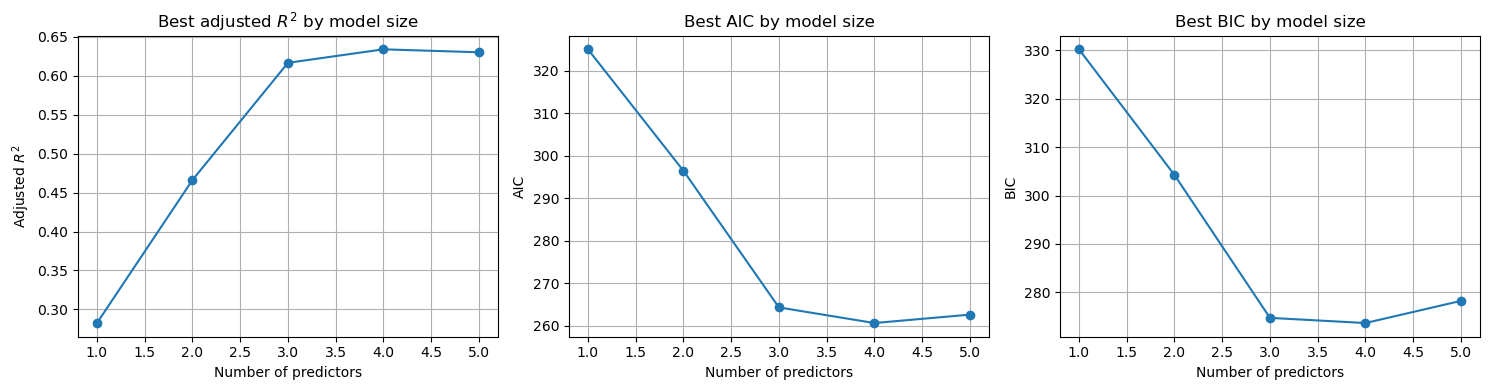

In [10]:
# Plot adjusted R^2, AIC, and BIC for the best model at each size
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(best_by_size["k"], best_by_size["Adj_R2"], marker="o")
axes[0].set_title("Best adjusted $R^2$ by model size")
axes[0].set_xlabel("Number of predictors")
axes[0].set_ylabel("Adjusted $R^2$")
axes[0].grid(True)

axes[1].plot(best_by_size["k"], best_by_size["AIC"], marker="o")
axes[1].set_title("Best AIC by model size")
axes[1].set_xlabel("Number of predictors")
axes[1].set_ylabel("AIC")
axes[1].grid(True)

axes[2].plot(best_by_size["k"], best_by_size["BIC"], marker="o")
axes[2].set_title("Best BIC by model size")
axes[2].set_xlabel("Number of predictors")
axes[2].set_ylabel("BIC")
axes[2].grid(True)

plt.tight_layout()
plt.show()

The plots summarize the trade-off between fit and parsimony.

If adjusted $R^2$ rises only slightly when a new variable is added, while AIC or BIC worsen, then that additional variable is not attractive.

In [11]:
# Forward selection using AIC
def forward_selection_aic(candidates):
    remaining = list(candidates)
    selected = []
    current_model = fit_model(selected)
    current_aic = current_model.aic
    path = []

    while remaining:
        scored = []
        for candidate in remaining:
            trial = selected + [candidate]
            model = fit_model(trial)
            scored.append((model.aic, candidate, model))

        scored.sort(key=lambda x: x[0])
        best_aic, best_candidate, best_model = scored[0]

        if best_aic < current_aic:
            selected.append(best_candidate)
            remaining.remove(best_candidate)
            current_aic = best_aic
            path.append({
                "Step": len(selected),
                "Added variable": best_candidate,
                "Model": tuple(selected),
                "AIC": best_model.aic,
                "Adj_R2": best_model.rsquared_adj,
                "BIC": best_model.bic
            })
        else:
            break

    final_model = fit_model(selected)
    return pd.DataFrame(path), selected, final_model

forward_path, forward_selected, forward_model = forward_selection_aic(predictors)
forward_path

,Step,Added variable,Model,AIC,Adj_R2,BIC
0,1,X4,"(X4,)",325.028687,0.282529,330.239028
1,2,X3,"(X4, X3)",296.442510,0.466143,304.258021
2,3,X2,"(X4, X3, X2)",264.291054,0.616639,274.711735
3,4,X5,"(X4, X3, X2, X5)",260.616684,0.633974,273.642535


Forward selection starts from the intercept-only model and adds the predictor that most improves AIC at each step.

The search stops when adding another variable no longer improves AIC.

In [12]:
forward_selected

['X4', 'X3', 'X2', 'X5']

This is the final model selected by forward AIC.

In [13]:
# Final recommended model from the agreed criteria
final_predictors = list(best_aic["predictors"])
final_model = fit_model(final_predictors)

print("Selected predictors:", final_predictors)
print(final_model.summary())

Selected predictors: ['X2', 'X3', 'X4', 'X5']
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     43.87
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           8.29e-21
Time:                        12:35:52   Log-Likelihood:                -125.31
No. Observations:                 100   AIC:                             260.6
Df Residuals:                      95   BIC:                             273.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

The final fitted model is

$$
Y_i = \beta_0 + \sum_{j \in S} \beta_j X_{ji} + \varepsilon_i,
$$

where $S$ is the selected subset of predictors.

We report the full OLS summary for the chosen model, including coefficient estimates, adjusted $R^2$, AIC, and BIC.

In [14]:
# Compare the selected final model with the full model
full_model = fit_model(predictors)

comparison = pd.DataFrame({
    "Model": [
        "Selected model",
        "Full model"
    ],
    "Predictors": [
        tuple(final_predictors),
        tuple(predictors)
    ],
    "Adjusted R^2": [
        final_model.rsquared_adj,
        full_model.rsquared_adj
    ],
    "AIC": [
        final_model.aic,
        full_model.aic
    ],
    "BIC": [
        final_model.bic,
        full_model.bic
    ]
})

comparison

,Model,Predictors,Adjusted R^2,AIC,BIC
0,Selected model,"(X2, X3, X4, X5)",0.633974,260.616684,273.642535
1,Full model,"(X1, X2, X3, X4, X5)",0.630170,262.592528,278.223549


This comparison is important because a good model-selection exercise should show not only what was chosen, but also **why it is preferred to the full model**.

If the selected model has better adjusted $R^2$, lower AIC, and lower BIC than the full model, then the excluded predictors did not add enough explanatory value to justify their complexity.

## Conclusion

Using the assigned dataset, we applied two justified model-selection approaches:

1. **Exhaustive best-subset selection**, evaluated by adjusted $R^2$, AIC, and BIC.
2. **Forward selection using AIC**.

All three subset criteria selected the same model, and forward AIC reached the same final subset. Therefore, the recommended regression model is strongly supported by multiple methods rather than trial-and-error selection.